# Preprocesamiento

In [35]:
import pandas as pd

In [36]:
df_rick = pd.read_csv("../data/processed/rick_data_imput.csv")

print(f"Shape of the DataFrame: {df_rick.shape}")
df_rick.head(5)

Shape of the DataFrame: (2631, 190)


,ide_id,ide_sex,ide_eda_ano,des_cal,ide_col,des_jur_res,des_mpo_res,cve_loc_res,des_loc_res,ide_cp,...,dias_estudio,demora_pac,demora_pac_fiebre,demora_pac_signos_alarma,fec_ini_estudio_corr,fec_fin_estudio_corr,fec_sol_aten_corr,fec_ini_signos_alarma_corr,fec_ini_signos_sint_corr,fec_ini_fiebre_corr
0,928424,1,39,CALLE,PASEOS DEL PEDREGAL Fraccionamiento,HERMOSILLO,HERMOSILLO,289,HERMOSILLO,83118.0,...,7.0,2,2.0,1.0,False,False,False,False,False,False
1,928745,2,8,CALLE,SAN RAFAEL Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83557.0,...,NaN,1,1.0,NaN,False,False,False,False,False,False
2,928768,2,2,CALLE,EL BOSQUE (CALLE QUINCE) Ejido,CAJEME,CAJEME,365,QUETCHEHUECA,85207.0,...,0.0,3,3.0,NaN,False,False,False,False,False,False
3,929029,1,9,PRIVADA,PUERTO PEÑASCO CENTRO Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83550.0,...,NaN,3,2.0,NaN,False,False,False,False,False,False
4,929184,2,13,CALLE,PALO BLANCO Congregación,NAVOJOA,NAVOJOA,124,TESIA,85235.0,...,24.0,8,8.0,NaN,False,False,False,False,False,False


In [37]:
def check_if_column_exists(df_columns, columns_name) -> dict:
    results = {}
    for column in columns_name:
        if column in df_columns:
            results[column] = "Exists"
        else:
            results[column] = "Does not exist"
    return results

Descripción de variables de texto y algunas categóricas.

|<center>Variable</center>|<center>Razón</center>|
|:------------------------|:---------------------|
|ide_id| Identificador único, no informativo|
|des_cal, ide_col|Texto libre de calle/colonia, alta cardinalidad sin valor agregado sobre municipio|
|des_cual_lengua|Texto libre redundante con lengua_indigena|
|contacto_otr|Texto libre, mejor codificar como binaria "tuvo contacto con otro animal"|
otro_sintoma, otros_especifique, otr_serv_atencion|Texto libre, difícil de modelar; opcional convertir a "tiene_otro_sintoma" binaria|
cve_uni_med_trat, des_uni_med_trat|Identificador de unidad, puede introducir sesgo de centrodes_ins_uni_trat_normNormalización del nombre de la institución, redundante|

In [38]:
# Columnas de texto libre y categorías
text_columns_to_drop = ['ide_id', 'ide_cp', 'des_cal', 'ide_col',
                   'des_cual_lengua', 'contacto_otr', 'otro_sintoma',
                   'otros_especifique', 'otr_serv_atencion', 'cve_uni_med_tratante',
                   'des_unidad_tratante', 'des_ins_uni_trat']

# diagnósticos y resultados probables
diag_columns_to_drop = ['des_diag_final', 'cve_diag_hospit', 'estatus_caso']
# Columnas de fechas y defunción
state_columns_to_drop = ['fec_egreso', 'cve_egreso', 'fec_defuncion', 'cve_defuncion', 'evolucion', 'manejo']

# Resultados de laboratorio
results_columns_to_drop = ['muestra_laboratorio', 'fecha_toma_rickett_ser1', 'fecha_recep_rickett_ser1',
                           'fecha_resultado_rickett_ser1','fecha_toma_rickett_sangre', 'fecha_recep_rickett_sangre',
                           'mstra_rech_ricket_sangre', 'motiv_rech_ricket_sangre',
                           'fecha_resultado_rickett_rtpcr', 'ricket_especie_rtpcr']

candidate_to_target = ['rickett_resultado_ser1', 'ricket_cq_lesp', 'ricket_cq',
                       'res_final_ricket_rtpcr', 'res_final_ricket_inmuno']

# Umbral de varianza para eliminar columnas con poca variabilidad
low_var_columns_to_drop = []

other_columns_to_drop = ['embarazo', 'servic_atencion', 'des_ocupacion']

# Columnas de jurisdicción, municipio y localidad (solo zonas macro o endemicas de Rickettsia)
jurisdiction_columns_to_drop = ['des_mpo_res', 'cve_loc_res', 'des_loc_res']

df_rick_processed = df_rick.drop(columns=text_columns_to_drop + diag_columns_to_drop + state_columns_to_drop + results_columns_to_drop + other_columns_to_drop + jurisdiction_columns_to_drop)
print(f"Cantidad de columnas eliminadas: {df_rick.shape[1] - df_rick_processed.shape[1]} \n Cantidad de columnas restantes: {df_rick_processed.shape[1]}")

df_rick_processed.head(5)

Cantidad de columnas eliminadas: 37 
 Cantidad de columnas restantes: 153


,ide_sex,ide_eda_ano,des_jur_res,es_indigena,lengua_indigena,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,contacto_garrapata,agua_potable,...,dias_estudio,demora_pac,demora_pac_fiebre,demora_pac_signos_alarma,fec_ini_estudio_corr,fec_fin_estudio_corr,fec_sol_aten_corr,fec_ini_signos_alarma_corr,fec_ini_signos_sint_corr,fec_ini_fiebre_corr
0,1,39,HERMOSILLO,2,2,2022-01-02,2022-01-02,2022-01-09,1,2,...,7.0,2,2.0,1.0,False,False,False,False,False,False
1,2,8,SAN LUIS RIO COLORADO,2,2,2022-01-05,2022-01-05,NaN,1,1,...,NaN,1,1.0,NaN,False,False,False,False,False,False
2,2,2,CAJEME,2,2,2022-01-05,2022-01-06,2022-01-06,0,1,...,0.0,3,3.0,NaN,False,False,False,False,False,False
3,1,9,SAN LUIS RIO COLORADO,2,2,2022-01-10,2022-01-10,NaN,1,1,...,NaN,3,2.0,NaN,False,False,False,False,False,False
4,2,13,NAVOJOA,2,2,2022-01-13,2022-01-14,2022-02-07,1,1,...,24.0,8,8.0,NaN,False,False,False,False,False,False


In [39]:
varianzas = df_rick_processed.select_dtypes(include=['float64', 'int64']).var()
print(varianzas.sort_values(ascending=True))

cirrosis_hepatica          0.001519
enf_ulcero_peptica         0.002276
inmunosupresion            0.003788
enf_renal                  0.005671
es_indigena                0.017551
                          ...      
demora_pac_fiebre        271.973971
ide_eda_ano              382.481845
alt                    72046.323711
ast                   142362.313060
dhl                   809035.107480
Length: 127, dtype: float64


In [40]:
# Eliminar columnas numéricas con varianza muy baja (umbral empírico = 0.01)
# Los candidatos a target se protegen para no perderlos antes del modelado
VARIANCE_THRESHOLD = 0.01
protected = set(candidate_to_target)

eligible_cols = [
    c for c in df_rick_processed.select_dtypes(include=['float64', 'int64']).columns
    if c not in protected
]
variances = df_rick_processed[eligible_cols].var()
low_var_to_drop = variances[variances < VARIANCE_THRESHOLD].index.tolist()

df_rick_processed = df_rick_processed.drop(columns=low_var_to_drop, errors='ignore')
print(f"Columnas eliminadas por varianza < {VARIANCE_THRESHOLD}: {len(low_var_to_drop)}")
for c in low_var_to_drop:
    print(f"  - {c}  (var={variances[c]:.6f})")
print(f"\nColumnas restantes: {df_rick_processed.shape[1]}")

Columnas eliminadas por varianza < 0.01: 4
  - enf_ulcero_peptica  (var=0.002276)
  - enf_renal  (var=0.005671)
  - inmunosupresion  (var=0.003788)
  - cirrosis_hepatica  (var=0.001519)

Columnas restantes: 149


In [41]:
# Eliminar fechas crudas (los deltas de tiempo ya están calculados como features)
# y los indicadores de corrección (metadata de limpieza, no features clínicas)
date_raw_cols = [
    c for c in df_rick_processed.columns
    if c.startswith(('fec_', 'fecha')) and not c.endswith('_corr')
]
corr_cols = [c for c in df_rick_processed.columns if c.endswith('_corr')]

df_rick_processed = df_rick_processed.drop(
    columns=date_raw_cols + corr_cols, errors='ignore'
)
print(f"Fechas crudas eliminadas ({len(date_raw_cols)}): {date_raw_cols}")
print(f"Indicadores de corrección eliminados ({len(corr_cols)}): {corr_cols}")
print(f"\nShape final para modelado: {df_rick_processed.shape}")

Fechas crudas eliminadas (9): ['fec_sol_aten', 'fec_ini_estudio', 'fec_fin_estudio', 'fec_ini_signos_sint', 'fec_ini_fiebre', 'fec_ini_signos_alarma', 'fec_ingreso', 'fec_ini_trat_ricket', 'fec_fin_trat_ricket']
Indicadores de corrección eliminados (6): ['fec_ini_estudio_corr', 'fec_fin_estudio_corr', 'fec_sol_aten_corr', 'fec_ini_signos_alarma_corr', 'fec_ini_signos_sint_corr', 'fec_ini_fiebre_corr']

Shape final para modelado: (2631, 134)


## Exploración de candidatos a variable objetivo

Se evalúan distintos resultados de laboratorio como posibles *targets* de clasificación.  
Los valores de CQ (ciclo umbral de PCR) se excluyen como target porque son variables continuas y los registros NaN mezclan "resultado negativo" con "muestra no tomada".

In [42]:
print("=== Candidatos a variable objetivo ===\n")
for col in candidate_to_target:
    if col not in df_rick_processed.columns:
        print(f"• {col}  → no encontrada en df_rick_processed\n")
        continue
    s = df_rick_processed[col]
    n_null = s.isna().sum()
    pct_null = s.isna().mean()
    vc = s.value_counts(dropna=False)
    print(f"• {col}  (tipo: {s.dtype})")
    print(f"  Nulos: {n_null:,} ({pct_null:.1%})")
    print(f"  Distribución:\n{vc.to_string()}")
    print()

=== Candidatos a variable objetivo ===

• rickett_resultado_ser1  (tipo: float64)
  Nulos: 191 (7.3%)
  Distribución:
rickett_resultado_ser1
0.0    1449
2.0     836
NaN     191
1.0     155

• ricket_cq_lesp  (tipo: float64)
  Nulos: 191 (7.3%)
  Distribución:
ricket_cq_lesp
0.00     1982
NaN       191
32.02       4
29.00       3
36.09       3
35.00       3
36.02       3
36.90       3
30.44       3
31.70       2
31.08       2
31.81       2
29.34       2
34.17       2
28.53       2
36.07       2
29.01       2
33.13       2
36.69       2
29.47       2
32.09       2
34.67       2
0.01        2
33.74       2
34.96       2
27.21       2
31.23       2
32.95       2
32.23       2
35.22       2
35.06       2
37.48       2
28.62       2
33.68       2
36.63       2
37.62       2
30.22       2
33.34       2
34.87       2
34.62       2
35.83       2
34.25       2
36.72       2
28.55       2
37.35       2
31.74       2
31.86       2
36.30       2
29.09       2
36.04       2
36.44       2
26.52      

In [43]:
# Mapas de binarización: 1 = Positivo (caso), 0 = Negativo
target_configs = {}

# RT-PCR: 1=Positivo, 2=Negativo, 3=Indeterminado → Positivo vs No-positivo
col = 'res_final_ricket_rtpcr'
if col in df_rick_processed.columns and df_rick_processed[col].notna().sum() >= 50:
    target_configs[col] = {
        'map': {1: 1, 2: 0, 3: 0},
        'label': 'RT-PCR (positivo vs negativo/indeterminado)'
    }

# Serología suero 1: 1=Positivo, 2=Negativo
col = 'rickett_resultado_ser1'
if col in df_rick_processed.columns and df_rick_processed[col].notna().sum() >= 50:
    target_configs[col] = {
        'map': {1: 1, 2: 0},
        'label': 'Serología IgG ser1 (positivo vs negativo)'
    }

# IFI: 1=Positivo, 2=Negativo
col = 'res_final_ricket_inmuno'
if col in df_rick_processed.columns and df_rick_processed[col].notna().sum() >= 50:
    target_configs[col] = {
        'map': {1: 1, 2: 0},
        'label': 'Inmunofluorescencia IFI (positivo vs negativo)'
    }

# CQ (valor continuo) → omitidos como target directo:
# un CQ presente implica PCR corrido y positivo; NaN mezcla "negativo" con "sin muestra"
for col in ['ricket_cq_lesp', 'ricket_cq']:
    if col in df_rick_processed.columns:
        n = df_rick_processed[col].notna().sum()
        print(f"  {col}: {n:,} valores no-nulos — omitido como target (continuo; NaN ≠ negativo)")

print("\nTargets a evaluar:")
for k, v in target_configs.items():
    n = df_rick_processed[k].notna().sum()
    vc = df_rick_processed[k].value_counts(dropna=True)
    print(f"  • {k}: {v['label']}  ({n:,} registros con valor)")
    print(f"    Distribución: {vc.to_dict()}")

  ricket_cq_lesp: 2,440 valores no-nulos — omitido como target (continuo; NaN ≠ negativo)
  ricket_cq: 2,440 valores no-nulos — omitido como target (continuo; NaN ≠ negativo)

Targets a evaluar:
  • res_final_ricket_rtpcr: RT-PCR (positivo vs negativo/indeterminado)  (2,440 registros con valor)
    Distribución: {2.0: 1761, 1.0: 479, 0.0: 196, 3.0: 4}
  • rickett_resultado_ser1: Serología IgG ser1 (positivo vs negativo)  (2,440 registros con valor)
    Distribución: {0.0: 1449, 2.0: 836, 1.0: 155}
  • res_final_ricket_inmuno: Inmunofluorescencia IFI (positivo vs negativo)  (2,440 registros con valor)
    Distribución: {0.0: 2378, 2.0: 36, 1.0: 26}


# Modelo

In [45]:
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
import numpy as np
import matplotlib.pyplot as plt

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost disponible")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost no instalado — instalar con: uv add xgboost")

✅ XGBoost disponible


## Entrenamiento por candidato a variable objetivo

Para cada target viable se aplica el mismo pipeline:
1. Binarizar la variable objetivo (Positivo=1, Negativo/Indeterminado=0) y descartar filas sin valor
2. Excluir **todos** los candidatos a target de X (evita *data leakage* entre resultados de laboratorio)
3. Manejar desbalance: `class_weight='balanced'` en modelos sklearn; `scale_pos_weight=neg/pos` en XGBoost
4. `GridSearchCV` 5-fold con `scoring='roc_auc'`

> **Prioridad clínica:** Recall ≥ 0.90 — un falso negativo en rickettsiosis puede ser fatal.

In [46]:
# ============================================================
# Entrenamiento iterativo sobre candidatos a variable objetivo
# ============================================================

all_results = {}

for target_col, cfg in target_configs.items():
    print(f"\n{'='*60}")
    print(f"TARGET: {cfg['label']}")
    print(f"{'='*60}")

    # Binarizar y filtrar filas sin valor definido en el target
    y_series = df_rick_processed[target_col].map(cfg['map'])
    mask = y_series.notna()

    if mask.sum() < 50:
        print(f"  ⚠️ Solo {mask.sum()} registros disponibles — omitiendo.")
        all_results[target_col] = {'results': [], 'best_models': {}, 'X_train': None, 'y_train': None}
        continue

    # Excluir todos los candidatos a target de X para evitar data leakage
    X_cols = [c for c in df_rick_processed.columns if c not in candidate_to_target]
    X_full = df_rick_processed.loc[mask, X_cols].copy()
    y_full = y_series[mask].astype(int)

    pos = (y_full == 1).sum()
    neg = (y_full == 0).sum()
    spw = neg / pos if pos > 0 else 1.0
    print(f"  Registros: {len(y_full):,} | Positivos: {pos:,} | Negativos: {neg:,} | Ratio neg/pos: {spw:.2f}")

    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
    )

    numeric_cols  = X_train.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler())
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_cols)
    ])

    # Modelos con manejo de desbalance de clases
    # sklearn: class_weight='balanced' repondera automáticamente cada muestra
    # XGBoost: scale_pos_weight = neg/pos compensa el desbalance en el gradiente
    model_grids_local = {
        "Logistic Regression": {
            "model": LogisticRegression(max_iter=5000, class_weight='balanced'),
            "params": {
                "model__C": [0.01, 0.1, 1, 10],
                "model__solver": ["liblinear", "lbfgs"]
            }
        },
        "Random Forest": {
            "model": RandomForestClassifier(random_state=42, class_weight='balanced'),
            "params": {
                "model__n_estimators": [100, 300],
                "model__max_depth": [None, 10, 20],
                "model__min_samples_split": [2, 5],
            }
        },
        "SVM": {
            "model": SVC(probability=True, class_weight='balanced'),
            "params": {
                "model__C": [0.1, 1, 10],
                "model__kernel": ["linear", "rbf"],
                "model__gamma": ["scale", "auto"]
            }
        },
        "Gradient Boosting": {
            "model": GradientBoostingClassifier(random_state=42),
            "params": {
                "model__n_estimators": [100, 200],
                "model__learning_rate": [0.05, 0.1],
                "model__max_depth": [3, 5]
            }
        },
    }

    if XGBOOST_AVAILABLE:
        model_grids_local["XGBoost"] = {
            "model": XGBClassifier(
                random_state=42,
                eval_metric='logloss',
                scale_pos_weight=spw,   # compensa el desbalance neg/pos
                verbosity=0
            ),
            "params": {
                "model__n_estimators": [100, 200],
                "model__learning_rate": [0.05, 0.1],
                "model__max_depth": [3, 5],
                "model__subsample": [0.8, 1.0],
            }
        }

    target_results = []
    best_models_target = {}

    for name, config in model_grids_local.items():
        print(f"\n  [{name}]")
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", config["model"])
        ])
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=config["params"],
            cv=5,
            scoring="roc_auc",
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_

        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:, 1]

        rec  = recall_score(y_test, y_pred, zero_division=0)
        prec = precision_score(y_test, y_pred, zero_division=0)
        auc  = roc_auc_score(y_test, y_prob)
        f1   = f1_score(y_test, y_pred, zero_division=0)

        target_results.append({
            "Target":      target_col,
            "Model":       name,
            "Recall":      rec,
            "Precision":   prec,
            "F1":          f1,
            "ROC-AUC":     auc,
            "Accuracy":    accuracy_score(y_test, y_pred),
            "Best Params": grid_search.best_params_,
        })
        best_models_target[name] = best_model

        print(f"    Recall={rec:.3f} | Precision={prec:.3f} | F1={f1:.3f} | ROC-AUC={auc:.3f}")
        print(f"    Mejores params: {grid_search.best_params_}")
        print(classification_report(y_test, y_pred, zero_division=0))

    all_results[target_col] = {
        'results':     target_results,
        'best_models': best_models_target,
        'X_train':     X_train,
        'y_train':     y_train,
        'X_test':      X_test,
        'y_test':      y_test,
    }


TARGET: RT-PCR (positivo vs negativo/indeterminado)
  Registros: 2,244 | Positivos: 479 | Negativos: 1,765 | Ratio neg/pos: 3.68

  [Logistic Regression]
    Recall=0.802 | Precision=0.558 | F1=0.658 | ROC-AUC=0.882
    Mejores params: {'model__C': 0.01, 'model__solver': 'lbfgs'}
              precision    recall  f1-score   support

           0       0.94      0.83      0.88       353
           1       0.56      0.80      0.66        96

    accuracy                           0.82       449
   macro avg       0.75      0.81      0.77       449
weighted avg       0.86      0.82      0.83       449


  [Random Forest]
    Recall=0.667 | Precision=0.688 | F1=0.677 | ROC-AUC=0.894
    Mejores params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 300}
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       353
           1       0.69      0.67      0.68        96

    accuracy                           0.8

In [47]:
# Tabla comparativa ordenada por Recall descendente (prioridad clínica: minimizar falsos negativos)
all_dfs = [pd.DataFrame(data['results']) for data in all_results.values() if data['results']]
if all_dfs:
    results_consolidated = pd.concat(all_dfs, ignore_index=True)
    display(
        results_consolidated
        .sort_values(['Target', 'Recall'], ascending=[True, False])
        [['Target', 'Model', 'Recall', 'ROC-AUC', 'F1', 'Precision', 'Accuracy']]
        .round(3)
        .reset_index(drop=True)
    )
else:
    print("No hay resultados disponibles.")

,Target,Model,Recall,ROC-AUC,F1,Precision,Accuracy
0,res_final_ricket_inmuno,Logistic Regression,0.600,0.825,0.667,0.750,0.769
1,res_final_ricket_inmuno,SVM,0.600,0.250,0.600,0.600,0.692
2,res_final_ricket_inmuno,Gradient Boosting,0.600,0.800,0.667,0.750,0.769
3,res_final_ricket_inmuno,Random Forest,0.400,0.725,0.500,0.667,0.692
4,res_final_ricket_inmuno,XGBoost,0.400,0.775,0.500,0.667,0.692
5,res_final_ricket_rtpcr,SVM,0.812,0.885,0.667,0.565,0.826
6,res_final_ricket_rtpcr,Logistic Regression,0.802,0.882,0.658,0.558,0.822
7,res_final_ricket_rtpcr,XGBoost,0.792,0.880,0.688,0.608,0.846
8,res_final_ricket_rtpcr,Random Forest,0.667,0.894,0.677,0.688,0.864
9,res_final_ricket_rtpcr,Gradient Boosting,0.500,0.880,0.585,0.706,0.849


El mejor sería con `res_final_ricket_rtpcr` mediante SVM, ya que consigue detectar 81.2% de los enfermos (Recall) pero con un Accuracy de 56.5% (más falsos positivos), aunque puede ser mejor antender falsos positivos que descartarlos. A través de Random Forest hay un peligro en su Recall ya que es de 66.7%. Si se requiere algo sencillo y flexible sería `res_final_ricket_rtpcr` con XGBoost.

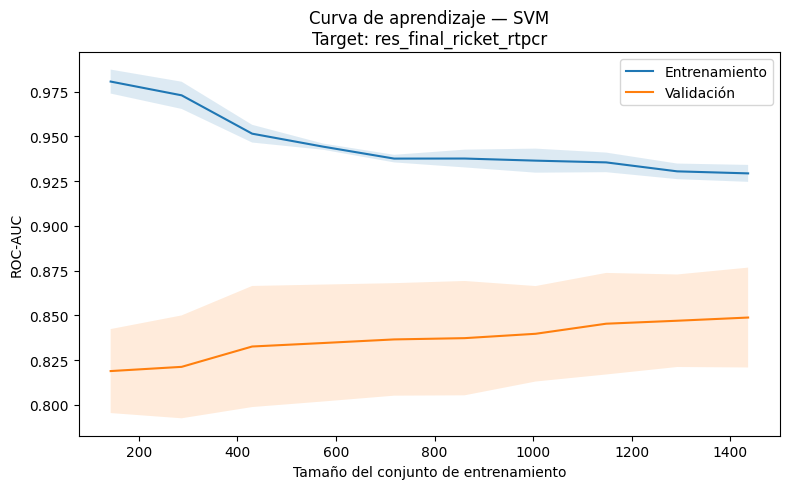

  Mejor Recall: 0.812 | ROC-AUC: 0.885
  Params: {'model__C': 1, 'model__gamma': 'auto', 'model__kernel': 'rbf'}



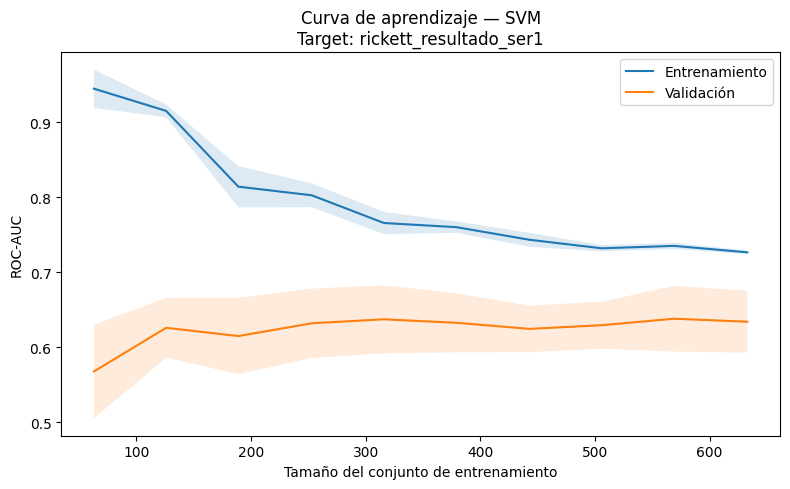

  Mejor Recall: 0.645 | ROC-AUC: 0.668
  Params: {'model__C': 0.1, 'model__gamma': 'auto', 'model__kernel': 'rbf'}



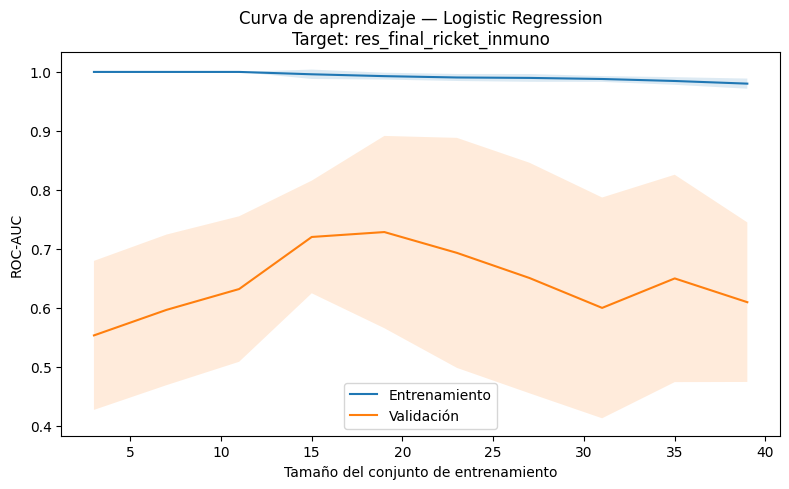

  Mejor Recall: 0.600 | ROC-AUC: 0.825
  Params: {'model__C': 0.01, 'model__solver': 'liblinear'}



In [48]:
# Curvas de aprendizaje del mejor modelo por target (ordenado por Recall descendente)
for target_col, data in all_results.items():
    if not data['results']:
        continue

    results_df_t = pd.DataFrame(data['results'])
    best_row = results_df_t.sort_values('Recall', ascending=False).iloc[0]
    best_name = best_row['Model']
    best_model = data['best_models'][best_name]

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=best_model,
        X=data['X_train'],
        y=data['y_train'],
        cv=5,
        scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(train_sizes, train_scores.mean(axis=1), label='Entrenamiento')
    ax.plot(train_sizes, val_scores.mean(axis=1), label='Validación')
    ax.fill_between(
        train_sizes,
        train_scores.mean(axis=1) - train_scores.std(axis=1),
        train_scores.mean(axis=1) + train_scores.std(axis=1),
        alpha=0.15
    )
    ax.fill_between(
        train_sizes,
        val_scores.mean(axis=1) - val_scores.std(axis=1),
        val_scores.mean(axis=1) + val_scores.std(axis=1),
        alpha=0.15
    )
    ax.set_title(f'Curva de aprendizaje — {best_name}\nTarget: {target_col}')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('ROC-AUC')
    ax.legend()
    fig.tight_layout()
    plt.show()
    print(f"  Mejor Recall: {best_row['Recall']:.3f} | ROC-AUC: {best_row['ROC-AUC']:.3f}")
    print(f"  Params: {best_row['Best Params']}\n")